In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from collections import defaultdict

In [2]:
# --- 5. Random Forest ---
def create_lagged_df(series, window):
    df = pd.DataFrame()
    for i in range(window):
        df[f"lag_{i+1}"] = series.shift(i + 1)
    df["target"] = series.values
    return df.dropna()

In [6]:
# --- 1. Load data ---
ticker = "^GSPC"
sp500 = yf.Ticker(ticker)
data = sp500.history(period="1y")["Close"]
data = data.dropna()
train_size = int(len(data) * 0.8)
base_train = data[0]
base_test = data[train_size]
#data = data.diff()[1:]/np.array(data[:-1])
#data = np.log(data[1:] / np.array(data[:-1]))

# --- 2. Train/Test Split ---

train, test = data[:train_size], data[train_size:]

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [ ]:
# --- 5. Random Forest ---
def create_lagged_df(series, window):
    df = pd.DataFrame()
    for i in range(window):
        df[f"lag_{i+1}"] = series.shift(i + 1)
    df["target"] = series.values
    return df.dropna()

#    window = 10  # lagged features

rf_list = defaultdict(list)
for window in list(range(1,4))+[30]:
    rf_data = create_lagged_df(data, window)
    train_rf = rf_data[:train_size - window]
    test_rf = rf_data[train_size - window:]

    X_train_rf, y_train_rf = train_rf.drop("target", axis=1), train_rf["target"]
    X_test_rf, y_test_rf = test_rf.drop("target", axis=1), test_rf["target"]
    n_test = y_test_rf.shape[0]
    
    rf_model = RandomForestRegressor()
    rf_model.fit(X_train_rf, y_train_rf)
    rf_pred = rf_model.predict(X_test_rf)
    rf_list['pred'].append(rf_pred)
    #rf_rmse = np.sqrt(mean_squared_error(base_test*np.exp(np.cumsum(y_test_rf)), base_test*np.exp(np.cumsum(rf_pred))))
    #rf_rmse = np.sqrt(1/np.arange(1,n_test+1)*np.cumsum((base_test*np.exp(np.cumsum(y_test_rf))- base_test*np.exp(np.cumsum(rf_pred)))**2))
    #rf_list['rmse'].append(rf_rmse)
    
# --- 7. Results ---
#for i in range(4):
    #print(f"Random Forest RMSE: {rf_list['rmse'][i][-1]:.4f}")

# --- 8. Plot (Optional) ---
plt.figure(figsize=(12, 6))
plt.plot(train.index, 
         #base_train*np.exp(np.cumsum(train)), 
         train,
         label="S&P 500 train")

plt.plot(test.index, 
         #base_test*np.exp(np.cumsum(test)), 
         test,
         label="Actual", color="black")
for i in range(4):
    plt.plot(test_rf.index, 
             #base_test*np.exp(np.cumsum(rf_list['pred'][i])),
             rf_list['pred'][i],
             c=mpl.colormaps['cool'](i/4),
             label="Random Forest",
             alpha=.5)
#plt.plot(test.index[-len(lstm_pred_rescaled):], lstm_pred_rescaled.flatten(), label="LSTM")
plt.title("S&P 500 Forecast Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [111]:
window = 1
rf_data = create_lagged_df(data, window)
train_rf = rf_data[:train_size - window]
test_rf = rf_data[train_size - window:]

X_train_rf, y_train_rf = train_rf.drop("target", axis=1), train_rf["target"]
X_test_rf, y_test_rf = test_rf.drop("target", axis=1), test_rf["target"]
n_test = y_test_rf.shape[0]
    
rf_model = RandomForestRegressor()
rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)

# Fit linear regression
lm_model = LinearRegression()
lm_model = lm_model.fit(X_train_rf, y_train_rf)
lm_pred = lm_model.predict(X_test_rf)

/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/9g/bj6gc6z17_1fyb7lx57xf04m0000gs/T/ipykernel_84356/3038380334.py:3: RuntimeWarning: overflow encountered in exp
  plt.plot(test_rf.index, base_test*np.exp(np.cumsum(rf_pred)),
/var/folders/9g/bj6gc6z17_1fyb7lx57xf04m0000gs/T/ipykernel_84356/3038380334.py:8: RuntimeWarning: overflow encountered in exp
  plt.plot(test_rf.index, base_test*np.exp(np.cumsum(lm_pred)),


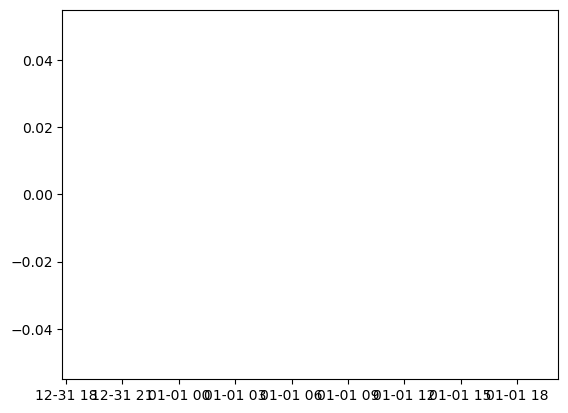

In [112]:
plt.plot(train.index, 
         base_train*np.exp(np.cumsum(train)), 
         label="S&P 500 train")
plt.plot(test.index, 
         base_test*np.exp(np.cumsum(test)), 
         label="Actual", color="black")
plt.plot(test_rf.index, base_test*np.exp(np.cumsum(rf_pred)), 
             c=mpl.colormaps['cool'](i/4),
             label="Random Forest",
             alpha=.5)

plt.plot(test_rf.index, base_test*np.exp(np.cumsum(lm_pred)), 
             c='r',
             label="Random Forest",
             alpha=.5)

In [102]:
alpha = .10
n = test.shape[0]
prop_cal = 0.10
n_cal = int(n * prop_cal)
smx = np.array(base_test*np.abs(np.exp(np.cumsum(test)) - np.exp(np.cumsum(rf_pred))))
smx_cal, smx_val = smx[:n_cal], smx[n_cal:]
q_hat = np.quantile(smx_cal, np.ceil((n_cal+1)*(1-alpha))/n_cal)
q_hat

218.90548363215817

In [103]:
val = base_test*np.exp(np.cumsum(rf_pred))[n_cal:]
val_low, val_up = val - q_hat, val + q_hat

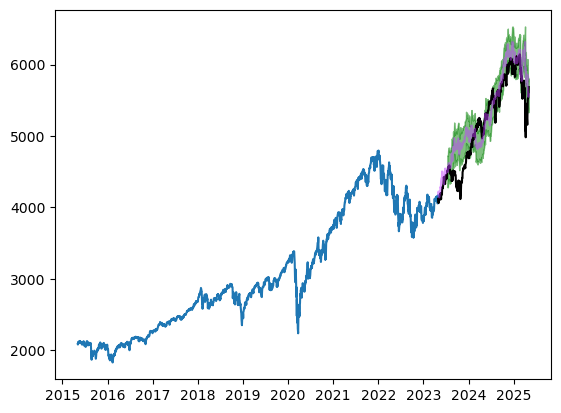

In [104]:
plt.plot(train.index, base_train*np.exp(np.cumsum(train)), label="S&P 500 train")
plt.plot(test.index, base_test*np.exp(np.cumsum(test)), label="Actual", color="black")
plt.plot(test_rf.index, base_test*np.exp(np.cumsum(rf_pred)), 
             c=mpl.colormaps['cool'](i/4),
             label="Random Forest",
             alpha=.5)

# Fill between the lines
plt.fill_between(test.index[n_cal:], 
                 val_low, 
                 val_up, color='green', alpha=0.5, label='Area between')

In [68]:
close_price = pd.read_csv('sp500_prices.csv').loc[:,'Close']

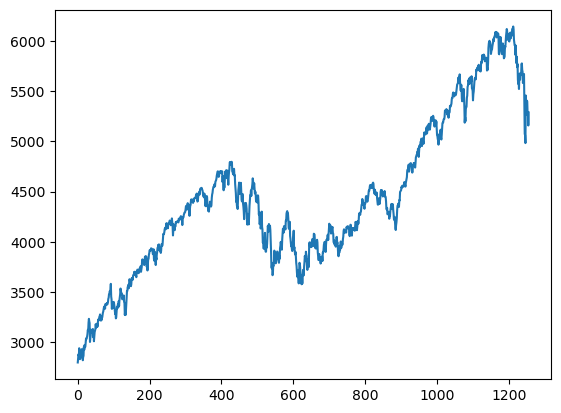

In [12]:
plt.plot(close_price)

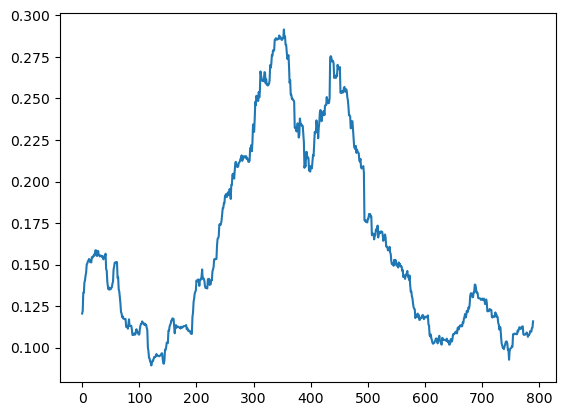

In [72]:
lookback = 60
plt.plot([np.std(returns[t - lookback:t])*np.sqrt(251) for t in range(lookback+150, 1000)]  )

In [15]:
from utils_ada_cp import *

In [29]:
returns = np.array(close_price)
returns = np.diff(np.log(returns), 1)
returns.shape

(1255,)

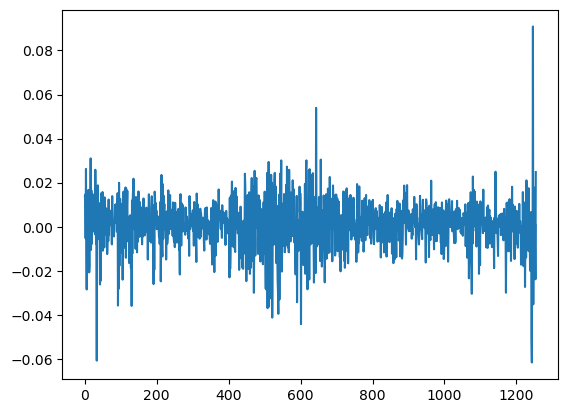

In [23]:
plt.plot(returns)

In [44]:
alpha_sequence, err_seq_oc, err_seq_nc = arima_conformal_forecasting(
    returns[:400], alpha=.1, gamma=.05, lookback=30,
    arima_order=(1,0,1), start_up=100, verbose=False,                            
    update_method="Simple", momentum_bw=0.95
)

Done 100 steps


/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

Done 200 steps


/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

Done 300 steps


ValueError: Quantiles must be in the range [0, 1]

In [40]:
np.mean(err_seq_oc)

0.09933774834437085

In [41]:
np.mean(err_seq_nc)

0.13245033112582782

In [42]:
alpha_sequence

array([0.1  , 0.105, 0.11 , 0.065, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.025, 0.03 , 0.035,
       0.04 , 0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 ,
       0.085, 0.04 , 0.045, 0.05 , 0.055, 0.06 , 0.015, 0.02 , 0.025,
       0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.055, 0.01 , 0.015, 0.02 ,
       0.025, 0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.055, 0.06 , 0.065,
       0.07 , 0.075, 0.08 , 0.085, 0.09 , 0.095, 0.1  , 0.055, 0.01 ,
       0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.055,
       0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085, 0.09 , 0.095, 0.1  ,
       0.105, 0.11 , 0.115, 0.12 , 0.125, 0.13 , 0.135, 0.14 , 0.145,
       0.15 , 0.155, 0.16 , 0.115, 0.12 , 0.075, 0.08 , 0.085, 0.09 ,
       0.095, 0.1  , 0.105, 0.11 , 0.115, 0.12 , 0.075, 0.08 , 0.085,
       0.09 , 0.095, 0.1  , 0.055, 0.06 , 0.065, 0.07 , 0.025, 0.03 ,
       0.035, 0.04 , 0.045, 0.05 , 0.055, 0.06 , 0.015, 0.02 , 0.025,
       0.03 , 0.035,